<a href="https://colab.research.google.com/github/nurfnick/NetworkScience/blob/main/Project/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from tabulate import tabulate

# Load data
df1 = pd.read_csv('https://raw.githubusercontent.com/nurfnick/NetworkScience/refs/heads/main/Project/policy_platforms.csv')
df2 = pd.read_csv('https://raw.githubusercontent.com/nurfnick/NetworkScience/refs/heads/main/Project/biographical_narratives.csv')

# Merge keys
merge_keys = ['candidate_webname', 'year']

# Identify columns unique to df2 (excluding merge keys)
df1_cols = set(df1.columns)
df2_cols = set(df2.columns)
only_in_df2 = list(df2_cols - df1_cols - set(merge_keys))

# Extract only the unique info from df2
df2_unique = df2[merge_keys + only_in_df2].drop_duplicates(subset=merge_keys)

# Merge into df1 — will replicate bio info across all matching policy rows
df1_merged = df1.merge(df2_unique, on=merge_keys, how='left')

print("✅ Merge complete.")
print("🧾 Rows in DF1 before merge:", len(df1))
print("🧾 Rows in DF1 after merge :", len(df1_merged))

df_2018 = df1_merged[df1_merged['year'] == 2018]
df_2020 = df1_merged[df1_merged['year'] == 2020]
df_2022 = df1_merged[df1_merged['year'] == 2022]

print(len(df_2018))
print(len(df_2020))
print(len(df_2022))

total_original = len(df1_merged)
total_split = len(df_2018) + len(df_2020) + len(df_2022)

print("✅ Total original rows:", total_original)
print("✅ Total after split   :", total_split)

# Confirm all rows are accounted for
if total_original == total_split:
    print("✅ All rows accounted for.")
else:
    print("⚠️  Mismatch! Some rows may be missing.")


✅ Merge complete.
🧾 Rows in DF1 before merge: 43465
🧾 Rows in DF1 after merge : 43465
15576
14037
13852
✅ Total original rows: 43465
✅ Total after split   : 43465
✅ All rows accounted for.


2018 Graph: 1499 nodes, 41537 edges
2020 Graph: 1447 nodes, 30501 edges
2022 Graph: 1558 nodes, 20025 edges


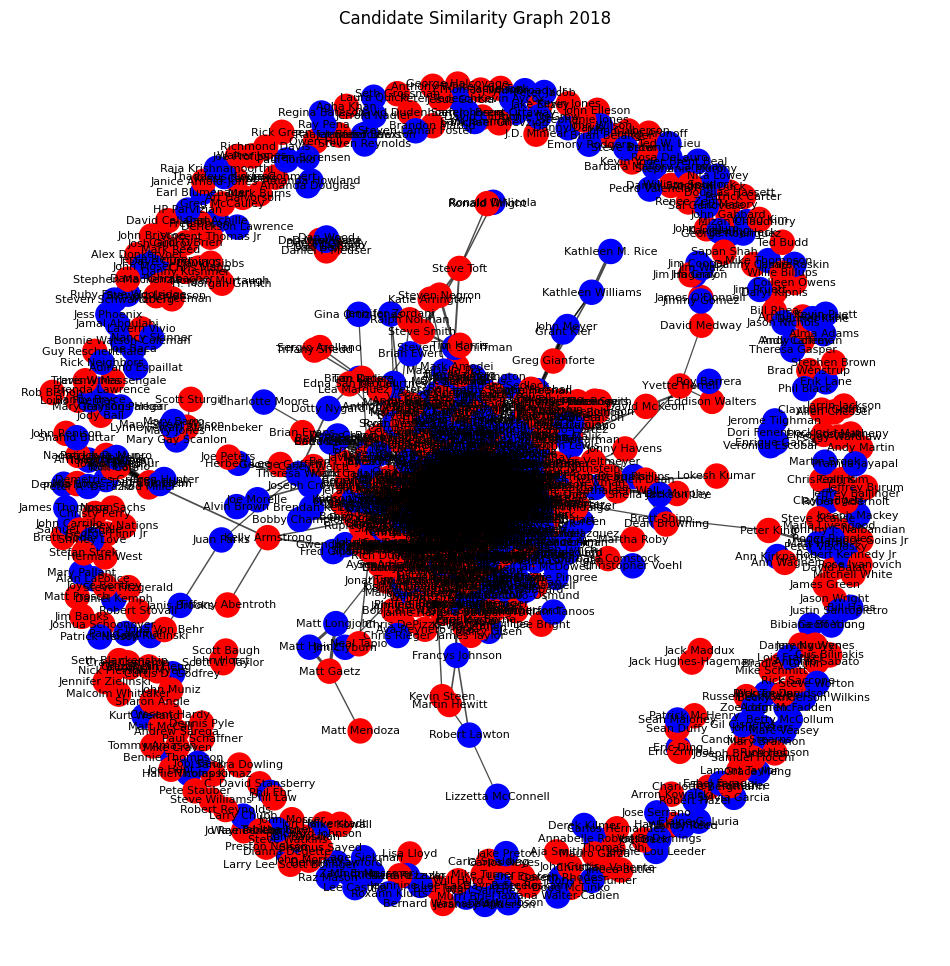

In [28]:
import pandas as pd

# Assuming df1_merged has the relevant columns

df1_merged['combined_issues'] = (
    df1_merged['issue_header'].fillna('') + ' ' +
    df1_merged['issue_text'].fillna('') + ' ' +
    df1_merged['policy_code'].fillna('')
)

candidate_issues = df1_merged.groupby(['candidate_webname', 'year', 'cand_party'])['combined_issues'].apply(lambda texts: ' '.join(texts)).reset_index()

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx

def build_similarity_graph(df, year, threshold=0.3):
    # Filter candidates from that year
    year_df = df[df['year'] == year].reset_index(drop=True)

    # Vectorize combined issues text
    vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
    tfidf_matrix = vectorizer.fit_transform(year_df['combined_issues'])

    # Compute cosine similarity (square matrix)
    sim_matrix = cosine_similarity(tfidf_matrix)

    # Build graph
    G = nx.Graph()

    # Add nodes: candidate names with year as suffix to avoid ambiguity I reintroduced the ambiguity to simplify the code added next
    nodes = [f"{row['candidate_webname']}" for _, row in year_df.iterrows()]
    G.add_nodes_from(nodes)

    # Adding political party as attribute to each node
    party_dict = year_df.set_index('candidate_webname')['cand_party'].to_dict()
    nx.set_node_attributes(G, party_dict, 'party')

    # Add edges where similarity > threshold (excluding self-loops)
    for i in range(len(nodes)):
        for j in range(i+1, len(nodes)):
            weight = sim_matrix[i, j]
            if weight > threshold:
                G.add_edge(nodes[i], nodes[j], weight=weight)



    return G

graph_2018 = build_similarity_graph(candidate_issues, 2018)
graph_2020 = build_similarity_graph(candidate_issues, 2020)
graph_2022 = build_similarity_graph(candidate_issues, 2022)

print(f"2018 Graph: {graph_2018.number_of_nodes()} nodes, {graph_2018.number_of_edges()} edges")
print(f"2020 Graph: {graph_2020.number_of_nodes()} nodes, {graph_2020.number_of_edges()} edges")
print(f"2022 Graph: {graph_2022.number_of_nodes()} nodes, {graph_2022.number_of_edges()} edges")

import matplotlib.pyplot as plt

def plot_graph(G, title):
    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(G, k=0.1)  # Layout adjustment
    weights = [G[u][v]['weight'] for u,v in G.edges()]
    color_map = {'Republican': 'red','Democrat': 'blue'}
    node_colors = [color_map[G.nodes[node]['party']] for node in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_size=300, node_color=node_colors)
    nx.draw_networkx_edges(G, pos, width=[w*3 for w in weights], alpha=0.7)
    nx.draw_networkx_labels(G, pos, font_size=8)
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_graph(graph_2018, "Candidate Similarity Graph 2018")


In [5]:
df1_merged.head()

,Unnamed: 0,candidate_webname,state_postal,cd,year,primary_type,dem_prez_vote,cand_party,inc,quality_cand,...,issue_header,issue_text,policy_code,statement_id,housegov_issue,FECCandID,BIOGUIDE_id,housegov_bio,biography_text,combined_issues
0,1,A. Donald McEachin,VA,4,2022,Open Primary,67.2,Democrat,1,2,...,CORONAVIRUS RELIEF,America is facing a grave health emergency wit...,Healthcare,1,0,H6VA04061,NaN,0.0,A community leader with a decades-long commitm...,CORONAVIRUS RELIEF America is facing a grave h...
1,2,A. Donald McEachin,VA,4,2022,Open Primary,67.2,Democrat,1,2,...,REDUCING INEQUITIES IN EDUCATION,Donald understands that good schools prepare c...,Education,2,0,H6VA04061,NaN,0.0,A community leader with a decades-long commitm...,REDUCING INEQUITIES IN EDUCATION Donald unders...
2,3,A. Donald McEachin,VA,4,2022,Open Primary,67.2,Democrat,1,2,...,FIGHTING FOR THE RIGHTS OF ALL VIRGINIANS,"For his entire career, Donald has been fightin...","Civil Rights, Liberties, and Minority Issues",3,0,H6VA04061,NaN,0.0,A community leader with a decades-long commitm...,FIGHTING FOR THE RIGHTS OF ALL VIRGINIANS For ...
3,4,A. Donald McEachin,VA,4,2022,Open Primary,67.2,Democrat,1,2,...,AFFORDABLE HEALTHCARE,Donald believes that affordable healthcare is ...,Healthcare,4,0,H6VA04061,NaN,0.0,A community leader with a decades-long commitm...,AFFORDABLE HEALTHCARE Donald believes that aff...
4,5,A. Donald McEachin,VA,4,2022,Open Primary,67.2,Democrat,1,2,...,PROTECTING OUR ENVIRONMENT,Donald is a stand out leader in the movement t...,Energy and Environment,5,0,H6VA04061,NaN,0.0,A community leader with a decades-long commitm...,PROTECTING OUR ENVIRONMENT Donald is a stand o...


In [22]:
candidate_party_dict = df1_merged.set_index('candidate_webname')['cand_party'].to_dict()

nx.set_node_attributes(graph_2018,candidate_party_dict, 'candidate_party')

In [24]:
graph_2018.nodes['A. Donald McEachin']

{'candidate_party': 'Democrat'}

In [18]:
nx.get_node_attributes(graph_2018, 'candidate_party')

{}

In [20]:
candidate_party_dict = df1_merged.set_index('candidate_webname')['cand_party'].to_dict()

# Display the first few items of the dictionary
list(candidate_party_dict.items())[:10]

[('A. Donald McEachin', 'Democrat'),
 ('A.J. Louderback', 'Republican'),
 ('Aarika Samone Rhodes', 'Democrat'),
 ('Aaron Bashir', 'Republican'),
 ('Aaron Storer', 'Republican'),
 ('Jamal Abdulahi', 'Democrat'),
 ('Abel Mulugheta', 'Democrat'),
 ('Kevin Abel', 'Democrat'),
 ('Tiffany Abentroth', 'Republican'),
 ('Kent Abernathy', 'Republican')]